In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from tqdm import tqdm
import numpy as np
import torch
from matplotlib import pyplot as plt

from lbm.models.lattice import D2Q9
from lbm.models.physics import PhysicalConfig, LatticeConfig, make_lattice_config

from lbm.core.equilibrium import feq_2nd_order
from lbm.core.macroscopic import macroscopic
from lbm.core.streaming import streaming
from lbm.core.collision import collision_bgk
from lbm.core.boundary_conditions import bounce_back_on_obstacles

In [3]:
physics = PhysicalConfig(
    L=0.01, W=0.01, d=0.004,
    rho=1e3, u=0.2, mu=1e-3, g=9.8
)

lattice = make_lattice_config(
    phys=physics, 
    lattice=D2Q9(), 
    dx=1.5e-5, 
    u_lattice=0.2
)

# Body force field. Gravity in y-direction
force = torch.zeros((lattice.Ny, lattice.Nx, 2), dtype=torch.float32)
lattice_g = physics.g * lattice.dt**2 / lattice.dx
force[...,-1] = lattice_g

print(physics)
print(lattice)

<class 'lbm.models.physics.PhysicalConfig'>:
            L: 0.01, W: 0.01, d: 0.004
            Re: 800.00
            nu: 0.00
        
<class 'lbm.models.physics.LatticeConfig'>:
            <Lattice D2Q9: dim=2, q=9>
            dx: 1.5e-05 (667 x 667) grids (rows x cols)
            dt: 1.5e-05 s/step
            tau: 0.700 (>0.55 for stability)
            Ma: 0.346 (<1.0 valid for incompressible system)
            nu_lattice: 0.233 (>0.0 for stability)
        


In [4]:
# --- Define obstacles Geometry  ---
from lbm.models.geometry import channel2D

Ny, Nx = lattice.Ny, lattice.Nx
# obstacles = cylinder2D(Nx, Ny, cx=Nx//2, cy=Ny//2, r=0.5 * physics_config.d / lattice_config.dx)
obstacles = channel2D(Nx, Ny, walls='left_right')

In [5]:
# --- Broadcast all variables to GPU before execution  ---
from lbm.utils import compute

device = compute.get_device()
lattice = compute.broadcast_to_device(lattice, device)
obstacles = compute.broadcast_to_device(obstacles, device)
force = compute.broadcast_to_device(force, device)

[PyTorch] Using device: mps (Apple MPS)


In [6]:
# --- Initiate state variables ---
rho = torch.full((Ny, Nx), lattice.rho, dtype=torch.float32, device=device)
ux  = torch.full((Ny, Nx), 0*lattice.u, dtype=torch.float32, device=device)  # flow in x
uy  = torch.zeros((Ny, Nx), dtype=torch.float32, device=device)            # no flow in y

# --- Initialise distribution function as equilibrium distribution ---
f = feq_2nd_order(rho, ux, uy, lattice.lattice)

# check mass conservation before execution
assert torch.allclose(rho.sum(), f.sum())

# --- Main LBM timestep loop ---
import time

u_sample = []
t_sample = []
dt = lattice.dt
t, t_max = 0, 100000

print(f'Starting time step loop. 1000 loops = {dt * 1000:.2f} physical second')
start = time.time()

# --- time loop ---
for i in tqdm(range(t_max)):
    rho, u = macroscopic(f, lattice.lattice, force=force)
    
    if t % 1000 == 0 or (t <= 1000 and t % 10 == 0):
        t_sample.append(t)
        u_sample.append(u.detach().clone().cpu().numpy())
        
    feq = feq_2nd_order(rho, ux, uy, lattice.lattice)
    
    # collision
    f_star = collision_bgk(f, feq, lattice.tau, force=force, lattice=lattice.lattice, u=u, rho=rho)
    
    # streaming
    f_next = streaming(f_star, lattice.lattice)
    
    # bounce back on obstacles
    bounce_back_on_obstacles(f_next, f_star, obstacles, lattice.lattice)
    f = f_next

    # check mass conservation and raise errors if not satisfied
    assert torch.allclose(rho.sum(), f.sum(), rtol=1e-3, atol=1e-8)
        
    t += 1  
duration = (time.time() - start)

print(f'Finish after {t} steps, equals to {t * dt:.3f} physical seconds')
print(f'Compute duration: {duration:.2f}s')

Starting time step loop. 1000 loops = 0.02 physical second


 20%|██████████████████████████▋                                                                                                           | 19905/100000 [06:47<27:18, 48.89it/s]


AssertionError: 

u_sample = np.array(u_sample)
t_sample = np.array(t_sample)
u_sample.shape

plt.plot(t_sample, u_sample[:, 50], label='y=50')
plt.plot(t_sample, u_sample[:, 30], label='y=30')
plt.plot(t_sample, u_sample[:, 10], label='y=10')
plt.plot(t_sample, u_sample[:, 5], label='y=5')
plt.legend()
plt.xlim([0,t_sample.max()])
plt.ylim([0, lattice.u * 1.05])
plt.grid()
plt.show()

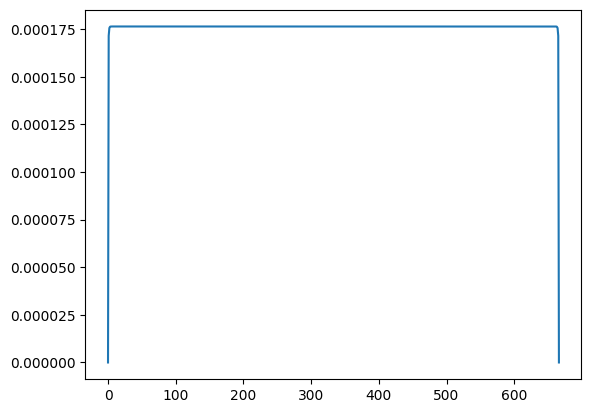

In [13]:
# velocity profile at end of iter
u_sample = np.array(u_sample) 
t_sample = np.array(t_sample) 
plt.plot(u_sample[-1, Ny//2, :, -1])